# Moog Ladder Filter (ZDF)

| Function | Description |
| --- | --- |
| `moog_ladder` | Zero-delay feedback 4-pole ladder filter (Moog/Minimoog emulation). |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.filters import moog_ladder
from python.generators import generate_impulse, generate_step

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

ZDF Moog ladder filter — frequency and time-domain responses.

Top row — frequency response (magnitude in dB, log-frequency x-axis):
  Left  : five resonance values at cutoff = 1000 Hz
            shows the resonant peak growing and DC gain dropping with k
  Right : three cutoff frequencies at resonance = 0.7
            shows the 24 dB/oct slope tracking the cutoff

Bottom row — time domain:
  Left  : impulse response at five resonance values (first 80 ms)
            shows ringing increasing and decay slowing as resonance → 1
  Right : step response at five resonance values (first 40 ms)
            shows the characteristic Moog "boing"; steady-state level is
            1/(1 + k) so higher resonance settles to a lower DC value

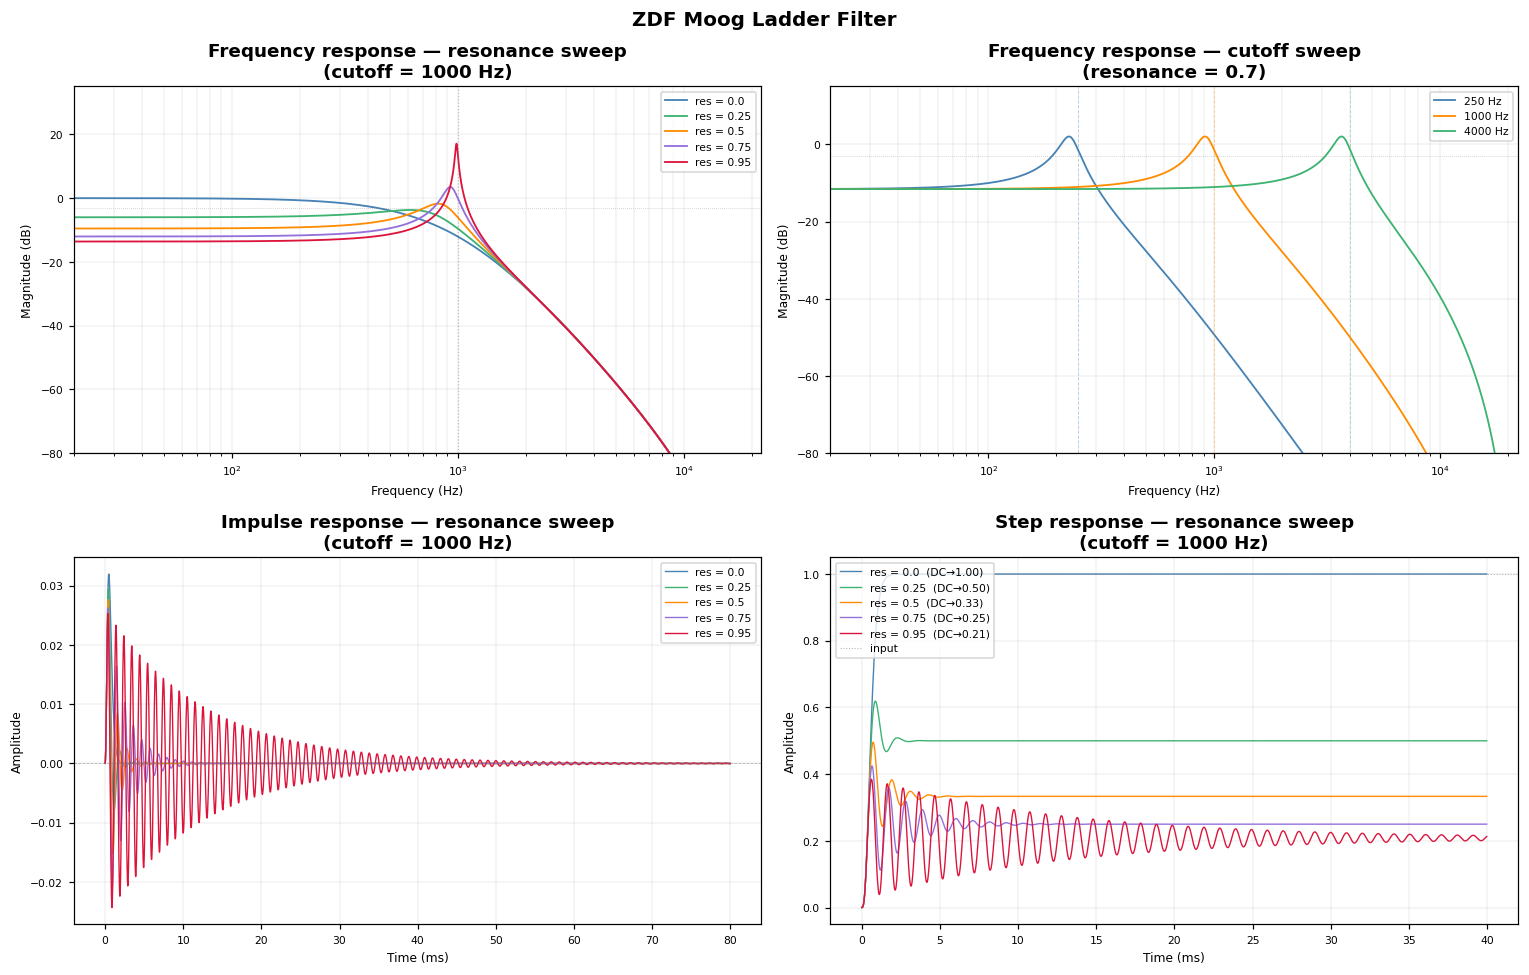

In [2]:
FS = 44100
DURATION = 1.0
CUTOFF = 1000.0

RESONANCES = [0.0, 0.25, 0.5, 0.75, 0.95]
RES_LABELS = [f"res = {r}" for r in RESONANCES]
RES_COLORS = ["steelblue", "mediumseagreen", "darkorange", "mediumpurple", "crimson"]

CUTOFFS = [250.0, 1000.0, 4000.0]
CUTOFF_COLORS = ["steelblue", "darkorange", "mediumseagreen"]


def _impulse() -> np.ndarray:
    _, imp = generate_impulse(fs=FS, duration=DURATION)
    return imp


def _step() -> np.ndarray:
    _, st = generate_step(fs=FS, duration=DURATION)
    return st


def _freq_response(h: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    spectrum = np.abs(np.fft.rfft(h))
    freqs = np.fft.rfftfreq(len(h), d=1.0 / FS)
    db = 20.0 * np.log10(spectrum + 1e-12)
    return freqs, db


def _plot_freq(ax, freqs, db, label, color, cutoff=None):
    mask = freqs > 0
    ax.semilogx(freqs[mask], db[mask], label=label, color=color, linewidth=1.2)
    if cutoff is not None:
        ax.axvline(cutoff, color=color, linewidth=0.6, linestyle="--", alpha=0.4)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))

imp = _impulse()
step = _step()

# ── [0,0] Frequency response: resonance sweep ─────────────────────────────────

ax = axes[0, 0]
for res, label, color in zip(RESONANCES, RES_LABELS, RES_COLORS):
    h = moog_ladder(imp, cutoff=CUTOFF, fs=FS, resonance=res)
    _plot_freq(ax, *_freq_response(h), label=label, color=color)
ax.axvline(CUTOFF, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)
ax.axhline(-3, color="gray", linewidth=0.5, linestyle=":", alpha=0.5)
ax.set_title(f"Frequency response — resonance sweep\n(cutoff = {int(CUTOFF)} Hz)", fontweight="bold")
ax.set_ylim(-80, 35)

# ── [0,1] Frequency response: cutoff sweep ────────────────────────────────────

ax = axes[0, 1]
for fc, color in zip(CUTOFFS, CUTOFF_COLORS):
    h = moog_ladder(imp, cutoff=fc, fs=FS, resonance=0.7)
    _plot_freq(ax, *_freq_response(h), label=f"{int(fc)} Hz", color=color, cutoff=fc)
ax.axhline(-3, color="gray", linewidth=0.5, linestyle=":", alpha=0.5)
ax.set_title("Frequency response — cutoff sweep\n(resonance = 0.7)", fontweight="bold")
ax.set_ylim(-80, 15)

for ax in axes[0]:
    ax.set_xlabel("Frequency (Hz)", fontsize=8)
    ax.set_ylabel("Magnitude (dB)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=7)
    ax.set_xlim(20, FS / 2)

# ── [1,0] Impulse response: resonance sweep ───────────────────────────────────

ax = axes[1, 0]
window_ms = 80
n = int(window_ms * FS / 1000)
t_ms = np.arange(n) / FS * 1000

for res, label, color in zip(RESONANCES, RES_LABELS, RES_COLORS):
    h = moog_ladder(imp, cutoff=CUTOFF, fs=FS, resonance=res)
    ax.plot(t_ms, h[:n], label=label, color=color, linewidth=0.9)

ax.set_title(f"Impulse response — resonance sweep\n(cutoff = {int(CUTOFF)} Hz)", fontweight="bold")
ax.set_xlabel("Time (ms)", fontsize=8)
ax.set_ylabel("Amplitude", fontsize=8)
ax.tick_params(labelsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)
ax.legend(fontsize=7)

# ── [1,1] Step response: resonance sweep ──────────────────────────────────────

ax = axes[1, 1]
window_ms = 40
n = int(window_ms * FS / 1000)
t_ms = np.arange(n) / FS * 1000

for res, label, color in zip(RESONANCES, RES_LABELS, RES_COLORS):
    h = moog_ladder(step, cutoff=CUTOFF, fs=FS, resonance=res)
    k = res * 4.0
    dc = 1.0 / (1.0 + k)
    ax.plot(t_ms, h[:n], label=f"{label}  (DC→{dc:.2f})", color=color, linewidth=0.9)

ax.axhline(1.0, color="gray", linewidth=0.7, linestyle=":", alpha=0.6, label="input")
ax.set_title(f"Step response — resonance sweep\n(cutoff = {int(CUTOFF)} Hz)", fontweight="bold")
ax.set_xlabel("Time (ms)", fontsize=8)
ax.set_ylabel("Amplitude", fontsize=8)
ax.tick_params(labelsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.legend(fontsize=7)

fig.suptitle("ZDF Moog Ladder Filter", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Three demonstrations of the Moog ladder's defining sonic characters.

A time-varying wrapper (`_moog_sweep`) is used to vary cutoff or resonance
per-sample while carrying filter state across the full signal.

| # | Signal | Cutoff | Resonance | What you hear |
| - | ------ | ------ | --------- | -------------- |
| 1 | Sawtooth A2 (110 Hz) | exponential sweep 80 → 8000 Hz | 0.7 | Classic Moog filter sweep — the filter opens up over the note |
| 2 | Sawtooth A2 (110 Hz) | fixed 800 Hz | linear sweep 0 → 0.95 | Transparency → ringing → near self-oscillation |
| 3 | White noise (tiny) | fixed 330 Hz (E4) | 1.0 | Filter self-oscillates — outputs a near-pure sinewave |

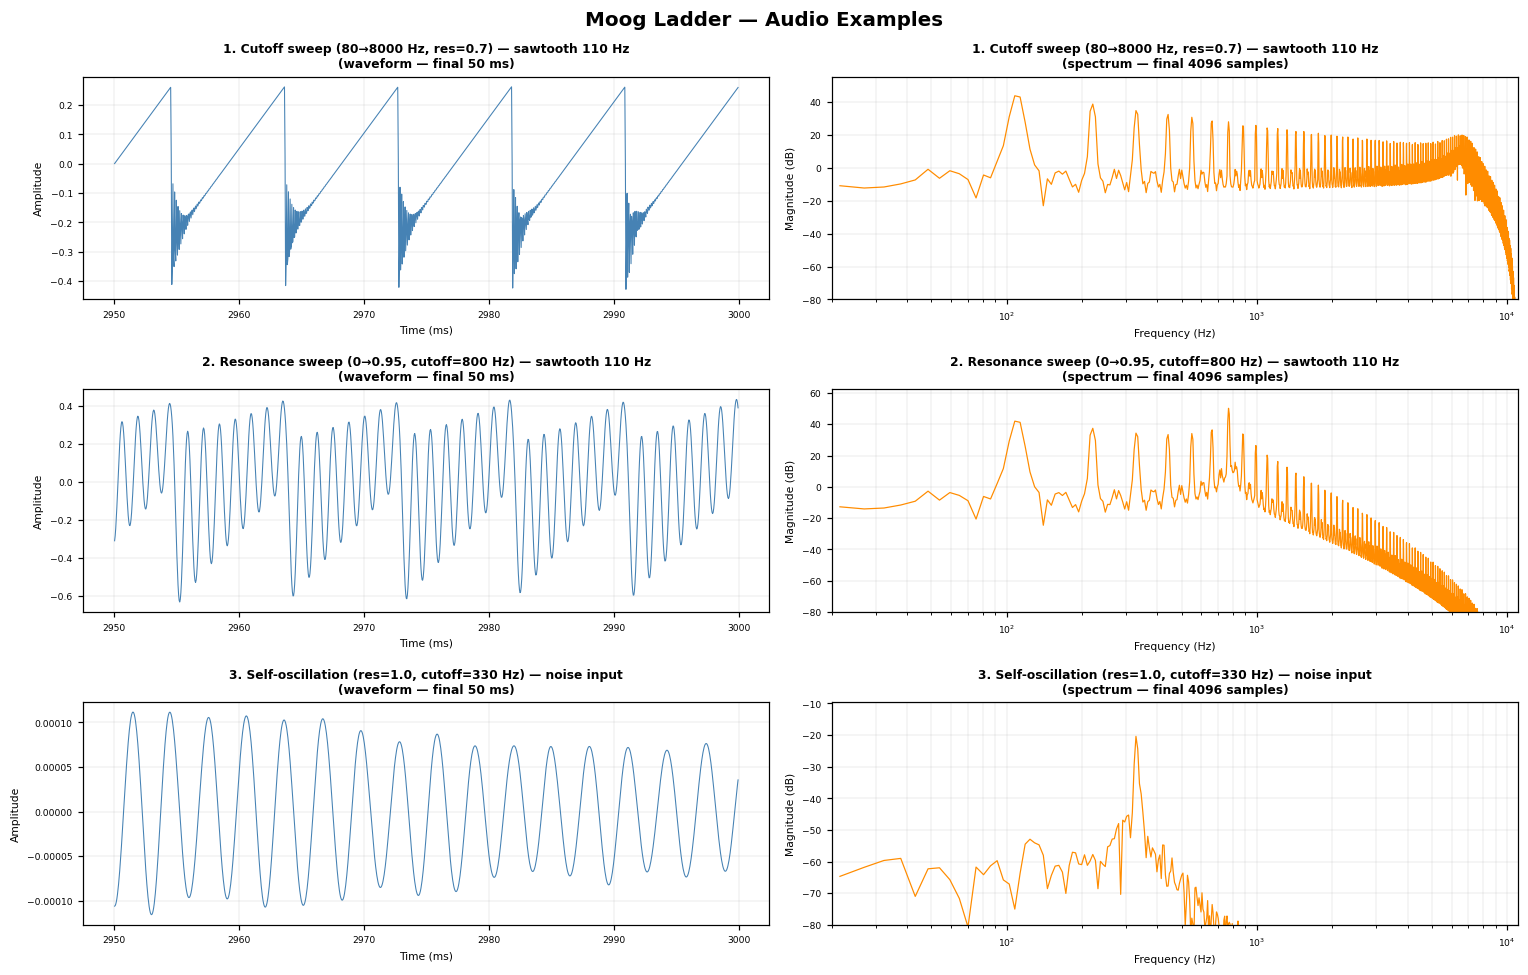

Example 1 — Cutoff sweep


Example 2 — Resonance sweep


Example 3 — Self-oscillation (330 Hz sinewave from noise)


In [3]:
from IPython.display import Audio, display

FS_AUDIO = 22050  # lower rate halves the Python loop count
DUR = 3.0


def _moog_sweep(
    signal: np.ndarray,
    cutoffs: np.ndarray,
    resonance: float,
    fs: int = FS_AUDIO,
) -> np.ndarray:
    """Sample-accurate moog ladder with time-varying cutoff."""
    k = resonance * 4.0
    s1 = s2 = s3 = s4 = 0.0
    out = np.empty(len(signal))
    for n, (x, fc) in enumerate(zip(signal, cutoffs)):
        g = np.tan(np.pi * fc / fs)
        G = g / (1.0 + g)
        inv_1pg = 1.0 / (1.0 + g)
        G2, G3, G4 = G * G, G * G * G, G * G * G * G
        denom = 1.0 + k * G4
        S1 = s1 * inv_1pg
        S2 = s2 * inv_1pg
        S3 = s3 * inv_1pg
        S4 = s4 * inv_1pg
        y4 = (G4 * x + G3 * S1 + G2 * S2 + G * S3 + S4) / denom
        u1 = x - k * y4
        v1 = (u1 - s1) * G;  y1 = v1 + s1;  s1 = y1 + v1
        v2 = (y1 - s2) * G;  y2 = v2 + s2;  s2 = y2 + v2
        v3 = (y2 - s3) * G;  y3 = v3 + s3;  s3 = y3 + v3
        v4 = (y3 - s4) * G;  y4 = v4 + s4;  s4 = y4 + v4
        out[n] = y4
    return out


def _normalise(x: np.ndarray) -> np.ndarray:
    peak = np.max(np.abs(x))
    return x / peak if peak > 1e-9 else x


def _sawtooth(freq: float, fs: int, dur: float) -> np.ndarray:
    t = np.arange(int(fs * dur)) / fs
    return 2 * ((freq * t) % 1.0) - 1.0


N = int(FS_AUDIO * DUR)
saw = _sawtooth(110.0, FS_AUDIO, DUR)

# ── 1. Cutoff sweep: 80 Hz → 8000 Hz, resonance = 0.7 ────────────────────────
cutoffs_sweep = np.geomspace(80.0, 8000.0, N)
audio1 = _moog_sweep(saw, cutoffs_sweep, resonance=0.7)

# ── 2. Resonance sweep: 0 → 0.95, cutoff fixed at 800 Hz ─────────────────────
cutoffs_fixed = np.full(N, 800.0)
res_env = np.linspace(0.0, 0.95, N)
k_env = res_env * 4.0
s1 = s2 = s3 = s4 = 0.0
audio2 = np.empty(N)
for n, (x, fc, k) in enumerate(zip(saw, cutoffs_fixed, k_env)):
    g = np.tan(np.pi * fc / FS_AUDIO)
    G = g / (1.0 + g)
    inv_1pg = 1.0 / (1.0 + g)
    G2, G3, G4 = G * G, G * G * G, G * G * G * G
    denom = 1.0 + k * G4
    S1 = s1 * inv_1pg; S2 = s2 * inv_1pg; S3 = s3 * inv_1pg; S4 = s4 * inv_1pg
    y4 = (G4 * x + G3 * S1 + G2 * S2 + G * S3 + S4) / denom
    u1 = x - k * y4
    v1 = (u1 - s1) * G;  y1 = v1 + s1;  s1 = y1 + v1
    v2 = (y1 - s2) * G;  y2 = v2 + s2;  s2 = y2 + v2
    v3 = (y2 - s3) * G;  y3 = v3 + s3;  s3 = y3 + v3
    v4 = (y3 - s4) * G;  y4 = v4 + s4;  s4 = y4 + v4
    audio2[n] = y4

# ── 3. Self-oscillation: resonance = 1.0, noise → sinewave ───────────────────
rng = np.random.default_rng(0)
noise = rng.standard_normal(N) * 1e-4
cutoffs_self = np.full(N, 330.0)  # E4
audio3 = _moog_sweep(noise, cutoffs_self, resonance=1.0)

# ── Plot waveform + spectrum for each example ─────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
t_ax = np.arange(N) / FS_AUDIO
window_s = 0.05  # 50 ms waveform window
n_win = int(window_s * FS_AUDIO)

examples = [
    (audio1, "1. Cutoff sweep (80→8000 Hz, res=0.7) — sawtooth 110 Hz"),
    (audio2, "2. Resonance sweep (0→0.95, cutoff=800 Hz) — sawtooth 110 Hz"),
    (audio3, "3. Self-oscillation (res=1.0, cutoff=330 Hz) — noise input"),
]

for row, (sig, title) in enumerate(examples):
    # Waveform — show tail end where effect is most pronounced
    ax_t = axes[row, 0]
    seg = sig[-n_win:]
    t_seg = t_ax[-n_win:]
    ax_t.plot(t_seg * 1000, seg, color="steelblue", linewidth=0.7)
    ax_t.set_title(f"{title}\n(waveform — final 50 ms)", fontweight="bold", fontsize=8)
    ax_t.set_xlabel("Time (ms)", fontsize=7)
    ax_t.set_ylabel("Amplitude", fontsize=7)
    ax_t.tick_params(labelsize=6)
    ax_t.grid(True, linewidth=0.3, alpha=0.5)

    # Spectrum — final 4096 samples
    ax_f = axes[row, 1]
    block = sig[-4096:] * np.hanning(4096)
    spec = np.abs(np.fft.rfft(block))
    freqs_f = np.fft.rfftfreq(4096, d=1.0 / FS_AUDIO)
    db_f = 20.0 * np.log10(spec + 1e-12)
    mask = freqs_f > 20
    ax_f.semilogx(freqs_f[mask], db_f[mask], color="darkorange", linewidth=0.8)
    ax_f.set_title(f"{title}\n(spectrum — final 4096 samples)", fontweight="bold", fontsize=8)
    ax_f.set_xlabel("Frequency (Hz)", fontsize=7)
    ax_f.set_ylabel("Magnitude (dB)", fontsize=7)
    ax_f.tick_params(labelsize=6)
    ax_f.grid(True, which="both", linewidth=0.3, alpha=0.5)
    ax_f.set_xlim(20, FS_AUDIO / 2)
    ax_f.set_ylim(-80, None)

fig.suptitle("Moog Ladder — Audio Examples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Playback widgets ──────────────────────────────────────────────────────────
print("Example 1 — Cutoff sweep")
display(Audio(_normalise(audio1), rate=FS_AUDIO))
print("Example 2 — Resonance sweep")
display(Audio(_normalise(audio2), rate=FS_AUDIO))
print("Example 3 — Self-oscillation (330 Hz sinewave from noise)")
display(Audio(_normalise(audio3), rate=FS_AUDIO))